In [1]:
import json
import numpy as np
import os
import pandas as pd

In [2]:
import json
import numpy as np
import os
import pandas as pd
import urllib.request
import urllib
import urllib.error
import urllib.parse
import urllib.response
from urllib.request import urlopen
# connect to poloniex's API
url = 'https://poloniex.com/public?command=returnChartData&currencyPair=USDT_BTC&start=1609430400&end=1625068800&period=900'

# parse json returned from the API to Pandas DF
openUrl = urlopen(url)
r = openUrl.read()
openUrl.close()
d = json.loads(r.decode())
df = pd.DataFrame(d)

original_columns=[u'close', u'date', u'high', u'low', u'open']
new_columns = ['Close','Timestamp','High','Low','Open']
df = df.loc[:,original_columns]
df.columns = new_columns
df.to_csv('bitcoin2020.csv',index=None, encoding="utf-8")

In [3]:
df.head(5)

,Close,Timestamp,High,Low,Open
0,28650.166249,1609430400,28813.590185,28626.723157,28774.071184
1,28634.955332,1609431300,28732.627836,28564.100414,28649.166278
2,28463.313750,1609432200,28681.998007,28463.313750,28645.891128
3,28384.280723,1609433100,28559.132322,28315.100000,28475.530204
4,28566.108762,1609434000,28566.108762,28375.256962,28375.447293


In [11]:
hist = df.set_index('Timestamp')
hist.index = pd.to_datetime(hist.index, unit='s')
target_col = 'Close'
hist.head(5)

,Close,High,Low,Open
Timestamp,,,,
2020-12-31 16:00:00,28650.166249,28813.590185,28626.723157,28774.071184
2020-12-31 16:15:00,28634.955332,28732.627836,28564.100414,28649.166278
2020-12-31 16:30:00,28463.313750,28681.998007,28463.313750,28645.891128
2020-12-31 16:45:00,28384.280723,28559.132322,28315.100000,28475.530204
2020-12-31 17:00:00,28566.108762,28566.108762,28375.256962,28375.447293


In [12]:
def train_test_split(df, test_size=0.2):
    split_row = len(df) - int(test_size * len(df))
    train_data = df.iloc[:split_row]
    test_data = df.iloc[split_row:]
    return train_data, test_data

In [13]:
train, test = train_test_split(hist, test_size=0.2)

In [44]:
def line_plot(line1, line2, label1=None, label2=None, title='', lw=2):
    fig, ax = plt.subplots(1, figsize=(13, 7))
    ax.plot(line1, label=label1, linewidth=lw)
    ax.plot(line2, label=label2, linewidth=lw)
    plt.xticks(fontsize=17)
    plt.yticks(fontsize=17)
    ax.set_ylabel('BTC 15mins Closing Price [USD]', fontsize=18)
    ax.set_title(title, fontsize=17)
    ax.legend(loc='best', fontsize=17);

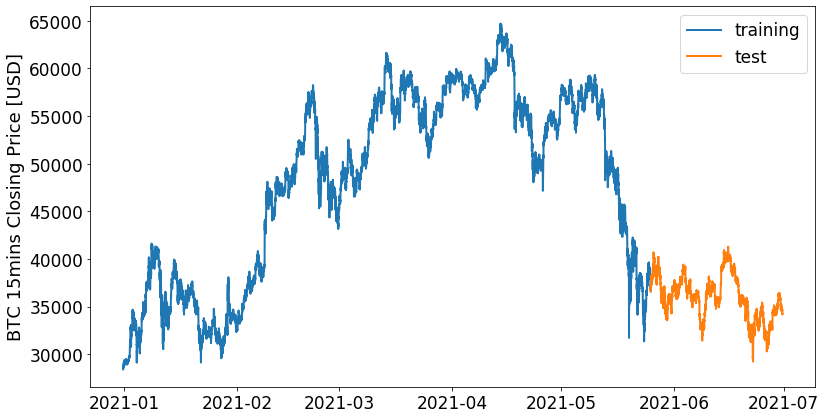

In [45]:
from keras.models import Sequential
from keras.layers import Activation, Dense, Dropout, LSTM
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import mean_absolute_error


line_plot(train[target_col], test[target_col], 'training', 'test', title='')
plt.savefig('my_plot.png',dpi=300)

In [9]:
#Data pre-processing - Normalisation
def normalise_zero_base(df):
    return df / df.iloc[0] - 1

def normalise_min_max(df):
    return (df - df.min()) / (data.max() - df.min())


In [10]:
def extract_window_data(df, window_len=5, zero_base=True):
    window_data = []
    for idx in range(len(df) - window_len):
        tmp = df[idx: (idx + window_len)].copy()
        if zero_base:
            tmp = normalise_zero_base(tmp)
        window_data.append(tmp.values)
    return np.array(window_data)

In [11]:
def prepare_data(df, target_col, window_len=10, zero_base=True, test_size=0.2):
    train_data, test_data = train_test_split(df, test_size=test_size)
    X_train = extract_window_data(train_data, window_len, zero_base)
    X_test = extract_window_data(test_data, window_len, zero_base)
    y_train = train_data[target_col][window_len:].values
    y_test = test_data[target_col][window_len:].values
    if zero_base:
        y_train = y_train / train_data[target_col][:-window_len].values - 1
        y_test = y_test / test_data[target_col][:-window_len].values - 1

    return train_data, test_data, X_train, X_test, y_train, y_test

In [12]:
def build_lstm_model(input_data, output_size, neurons=100, activ_func='linear',
                     dropout=0.2, loss='mse', optimizer='adam'):
    model = Sequential()
    model.add(LSTM(neurons, input_shape=(input_data.shape[1], input_data.shape[2])))
    model.add(Dropout(dropout))
    model.add(Dense(units=output_size))
    model.add(Activation(activ_func))

    model.compile(loss=loss, optimizer=optimizer)
    return model

In [13]:
np.random.seed(42)
window_len = 5
test_size = 0.2
zero_base = True
lstm_neurons = 100
epochs = 20
batch_size = 32
loss = 'mse'
dropout = 0.2
optimizer = 'adam'

In [15]:
train, test, X_train, X_test, y_train, y_test = prepare_data(
    hist, target_col, window_len=window_len, zero_base=zero_base, test_size=test_size)

In [16]:
model = build_lstm_model(
    X_train, output_size=1, neurons=lstm_neurons, dropout=dropout, loss=loss,
    optimizer=optimizer)
history = model.fit(
    X_train, y_train, validation_data=(X_test, y_test), epochs=epochs, batch_size=batch_size, verbose=1, shuffle=True)

Train on 13897 samples, validate on 3470 samples
Epoch 1/20
13897/13897 [==============================] - 13s 955us/step - loss: 6.0325e-05 - val_loss: 3.2704e-05
Epoch 2/20
13897/13897 [==============================] - 11s 778us/step - loss: 4.4174e-05 - val_loss: 3.0912e-05
Epoch 3/20
13897/13897 [==============================] - 11s 800us/step - loss: 4.2519e-05 - val_loss: 2.9275e-05
Epoch 4/20
13897/13897 [==============================] - 11s 799us/step - loss: 4.1200e-05 - val_loss: 2.9151e-05
Epoch 5/20
13897/13897 [==============================] - 13s 939us/step - loss: 4.1689e-05 - val_loss: 3.0531e-05
Epoch 6/20
13897/13897 [==============================] - 12s 898us/step - loss: 4.0917e-05 - val_loss: 2.9356e-05
Epoch 7/20
13897/13897 [==============================] - 16s 1ms/step - loss: 4.0838e-05 - val_loss: 2.8453e-05
Epoch 8/20
13897/13897 [==============================] - 15s 1ms/step - loss: 3.9887e-05 - val_loss: 2.8952e-05
Epoch 9/20
13897/13897 [===========

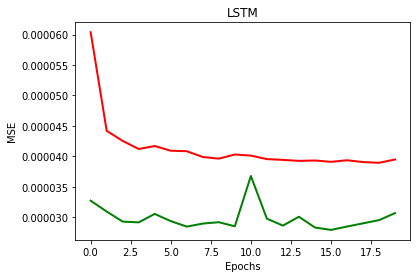

In [31]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'],'r',linewidth=2, label='Train loss')
plt.plot(history.history['val_loss'], 'g',linewidth=2, label='Validation loss')
plt.title('LSTM')
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.show()

In [36]:
targets = test[target_col][window_len:]
preds = model.predict(X_test).squeeze()
MAE=mean_absolute_error(preds, y_test)
MAE

0.004025656692051799

In [39]:
from sklearn.metrics import mean_squared_error
MSE=mean_squared_error(preds, y_test)
MSE
import math
RMSE=math.sqrt(MSE)
RMSE

0.005537829753011449

In [34]:
from sklearn.metrics import r2_score
R2=r2_score(y_test, preds)
R2

0.7790611762788653

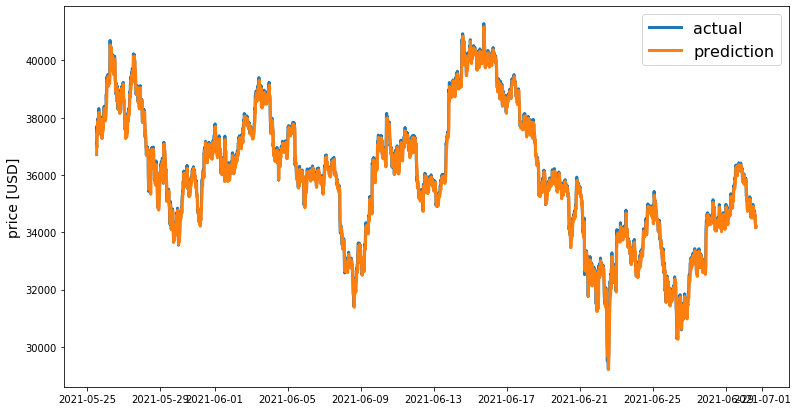

In [35]:
preds = test[target_col].values[:-window_len] * (preds + 1)
preds = pd.Series(index=targets.index, data=preds)
line_plot(targets, preds, 'actual', 'prediction', lw=3)

In [ ]:
#lstm, testset=0.2, dropout=0.2
#15mins data with 17,377 datapoints
#results are RMSE=0.005537829753011449; R2=0.7790611762788653

In [4]:
# NOW, TRY DAILY DATASET (4years)

In [17]:
from keras.models import Sequential
from keras.layers import Activation, Dense, Dropout, LSTM
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import mean_absolute_error
d = pd.DataFrame(pd.read_csv('bitcoin2018to2021.csv'))
d.head(5)


FileNotFoundError: [Errno 2] File bitcoin2018to2021.csv does not exist: 'bitcoin2018to2021.csv'

In [117]:
gold_price = pd.read_csv('Gold_Spot.csv')
gold_price

,Date,High,Low,gold_close
0,2018/1/1,"1,317.60","1,302.30","1,313.70"
1,2018/1/2,"1,317.60","1,302.30","1,313.70"
2,2018/1/3,"1,320.10","1,312.10","1,316.20"
3,2018/1/4,"1,322.00","1,319.40","1,319.40"
4,2018/1/5,"1,320.30","1,320.30","1,320.30"
...,...,...,...,...
1005,2021/12/27,"1,812.10","1,807.00","1,808.10"
1006,2021/12/28,"1,818.00","1,805.50","1,810.20"
1007,2021/12/29,"1,805.10","1,791.40","1,805.10"
1008,2021/12/30,"1,816.00","1,796.00","1,812.70"


In [3]:
d_result=pd.merge(d, gold_price, on='Date',how='left')
d_result.fillna(method='ffill',inplace=True)
d_result.head()
d_result.to_csv('btc_all_features.csv')


NameError: name 'd' is not defined

In [ ]:
############### from the following ###########

In [78]:
df_result=pd.read_csv('btc_all_feature.csv')
df_result.head()
prices=df_result['Close']
prices
test_prices=prices.iloc[1248:1462]
test_prices

1248    37575.17969
1249    39208.76563
1250    36894.40625
1251    35551.95703
1252    35862.37891
           ...     
1457    47588.85547
1458    46444.71094
1459    47178.12500
1460    46306.44531
1461    47686.81250
Name: Close, Length: 214, dtype: float64

In [50]:
import numpy as np
import pandas as pd
import seaborn as sns
import datetime as dt

df['Date'] = pd.to_datetime(df.Date)
df.head()
hist = df.set_index('Date')
hist.index = pd.to_datetime(hist.index, unit='s')
target_col = 'Log return'
hist.head(5)
hist.tail(5)

,Log return,Price change,Price volatility
Date,,,
2021-12-28,-0.062151,0.066582,0.040001
2021-12-29,-0.024336,0.040675,0.024431
2021-12-30,0.015668,0.038741,0.023269
2021-12-31,-0.018649,0.056263,0.033798
2022-01-01,0.029374,0.032701,0.019641


In [10]:
def train_test_split(df, test_size=0.15):
    split_row = len(df) - int(test_size * len(df))
    train_data = df.iloc[:split_row]
    test_data = df.iloc[split_row:]
    return train_data, test_data

In [11]:
train, test = train_test_split(hist, test_size=0.15)

In [12]:
def line_plot(line1, line2, label1=None, label2=None, title='', lw=2):
    fig, ax = plt.subplots(1, figsize=(13, 7))
    ax.plot(line1, label=label1, linewidth=lw)
    ax.plot(line2, label=label2, linewidth=lw)
    ax.set_ylabel('price [USD]', fontsize=14)
    ax.set_title(title, fontsize=16)
    ax.legend(loc='best', fontsize=16);


Using TensorFlow backend.


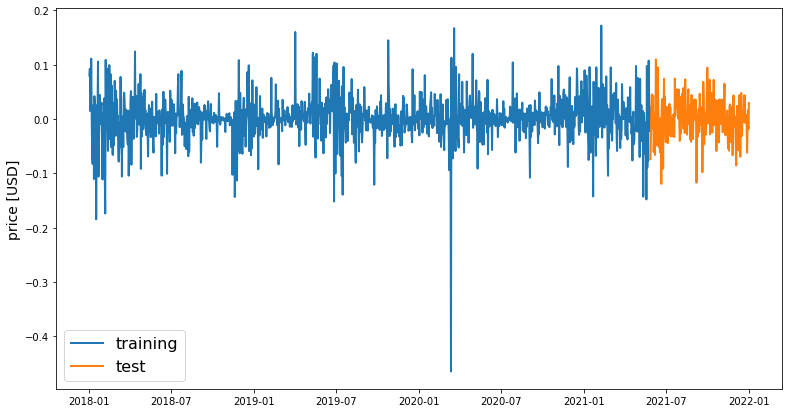

In [13]:
from keras.models import Sequential
from keras.layers import Activation, Dense, Dropout, LSTM
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import mean_absolute_error

line_plot(train[target_col], test[target_col], 'training', 'test', title='')

In [70]:
####### min_max scaler? or normalisation? #####
def normalise_zero_base(df):
    return df / df.iloc[0] - 1

def normalise_min_max(df):
    return (df - df.min()) / (data.max() - df.min())

,Date,Log return,Price change,Price volatility
0,2018-01-01,0.080000,0.070232,0.042196
1,2018-01-02,0.092589,0.159465,0.095972
2,2018-01-03,0.014505,0.047887,0.028765
3,2018-01-04,0.025858,0.080464,0.048350
4,2018-01-05,0.110945,0.152085,0.091513
5,2018-01-06,0.005578,0.054982,0.033028
6,2018-01-07,-0.061741,0.088626,0.053260
7,2018-01-08,-0.082675,0.151544,0.091186
8,2018-01-09,-0.038620,0.071754,0.043111
9,2018-01-10,0.025562,0.089456,0.053759


In [16]:
##### lag=5???######
def extract_window_data(df, window_len=5, zero_base=True):
    window_data = []
    for idx in range(len(df) - window_len):
        tmp = df[idx: (idx + window_len)].copy()
        if zero_base:
            tmp = normalise_zero_base(tmp)
        window_data.append(tmp.values)
    return np.array(window_data)

In [17]:
######## window_len=10??? #####
def prepare_data(df, target_col, window_len=10, zero_base=True, test_size=0.15):
    train_data, test_data = train_test_split(df, test_size=test_size)
    X_train = extract_window_data(train_data, window_len, zero_base)
    X_test = extract_window_data(test_data, window_len, zero_base)
    y_train = train_data[target_col][window_len:].values
    y_test = test_data[target_col][window_len:].values
    if zero_base:
        y_train = y_train / train_data[target_col][:-window_len].values - 1
        y_test = y_test / test_data[target_col][:-window_len].values - 1

    return train_data, test_data, X_train, X_test, y_train, y_test
# train_data
# test_data

# X_train <-> y_train
# X_test <-> y_test

In [18]:
#### single layer LSTM??? #######
def build_lstm_model(input_data, output_size, neurons=100, activ_func='linear',
                     dropout=0.05, loss='mse', optimizer='adam'):
    model = Sequential()
    model.add(LSTM(neurons, input_shape=(input_data.shape[1], input_data.shape[2])))
    model.add(Dropout(dropout))
    model.add(Dense(units=output_size))
    model.add(Activation(activ_func))

    model.compile(loss=loss, optimizer=optimizer)
    return model

In [19]:
np.random.seed(42)
window_len = 5
test_size = 0.15
zero_base = True
lstm_neurons = 100
epochs = 38
batch_size = 32
loss = 'mse'
dropout = 0.05
optimizer = 'adam'

In [57]:
train, test, X_train, X_test, y_train, y_test = prepare_data(
    hist, target_col, window_len=window_len, zero_base=zero_base, test_size=test_size)

In [58]:
model = build_lstm_model(
    X_train, output_size=1, neurons=lstm_neurons, dropout=dropout, loss=loss,
    optimizer=optimizer)
history = model.fit(
    X_train, y_train, validation_data=(X_test, y_test), epochs=epochs, batch_size=batch_size, verbose=2, shuffle=True)

Train on 1238 samples, validate on 214 samples
Epoch 1/38
 - 3s - loss: 454.1907 - val_loss: 181.5041
Epoch 2/38
 - 1s - loss: 452.1272 - val_loss: 178.8087
Epoch 3/38
 - 1s - loss: 450.0411 - val_loss: 179.1082
Epoch 4/38
 - 1s - loss: 446.9437 - val_loss: 178.0412
Epoch 5/38
 - 1s - loss: 444.7978 - val_loss: 177.9392
Epoch 6/38
 - 1s - loss: 442.3606 - val_loss: 176.4385
Epoch 7/38
 - 1s - loss: 440.3531 - val_loss: 176.1397
Epoch 8/38
 - 1s - loss: 437.7325 - val_loss: 174.8874
Epoch 9/38
 - 1s - loss: 436.1006 - val_loss: 175.7407
Epoch 10/38
 - 1s - loss: 434.0840 - val_loss: 175.2721
Epoch 11/38
 - 1s - loss: 430.3667 - val_loss: 174.8653
Epoch 12/38
 - 1s - loss: 429.4954 - val_loss: 175.1681
Epoch 13/38
 - 1s - loss: 426.8068 - val_loss: 174.0469
Epoch 14/38
 - 1s - loss: 424.6799 - val_loss: 172.6201
Epoch 15/38
 - 1s - loss: 421.9383 - val_loss: 171.2203
Epoch 16/38
 - 1s - loss: 419.5220 - val_loss: 169.8397
Epoch 17/38
 - 1s - loss: 418.5861 - val_loss: 171.8241
Epoch 18/3

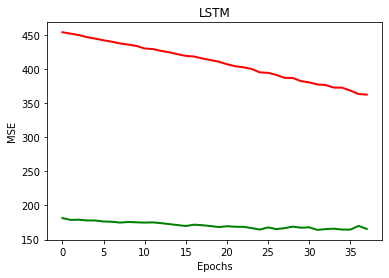

In [59]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'],'r',linewidth=2, label='Train loss')
plt.plot(history.history['val_loss'], 'g',linewidth=2, label='Validation loss')
plt.title('LSTM')
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.show()

In [72]:
targets = test[target_col][window_len:]
preds = model.predict(X_test).squeeze()
#### -> preds: prediction vector


In [101]:
test_prices[0]=prices[train_size+look_back-1]*math.exp(preds[0])
test_prices

1248    37575.179690
1249    39208.765630
1250    36894.406250
1251    35551.957030
1252    35862.378910
            ...     
1458    46444.710940
1459    47178.125000
1460    46306.445310
1461    47686.812500
0       16816.980702
Name: Close, Length: 215, dtype: float64

In [94]:
for i in range (1, len(test_prices)): 
    testPred_prices[i]=_prices[i-1]*math.exp(preds[i])

NameError: name 'preds_prices' is not defined

In [61]:
MAE=mean_absolute_error(preds, y_test)
MAE

4.577325310118647

In [62]:
from sklearn.metrics import mean_squared_error
MSE=mean_squared_error(preds, y_test)
MSE
import math
RMSE=math.sqrt(MSE)
RMSE

12.867807892496883

In [63]:
from sklearn.metrics import r2_score
R2=r2_score(y_test, preds)
R2

0.061694468750353226

In [64]:
preds = test[target_col].values[:-window_len] * (preds + 1)
preds = pd.Series(index=targets.index, data=preds)
preds

Date
2021-06-02   -0.012818
2021-06-03   -0.000563
2021-06-04    0.007632
2021-06-05   -0.030323
2021-06-06   -0.013018
                ...   
2021-12-28   -0.016374
2021-12-29    0.005912
2021-12-30    0.004387
2021-12-31    0.007188
2022-01-01   -0.051238
Length: 214, dtype: float64

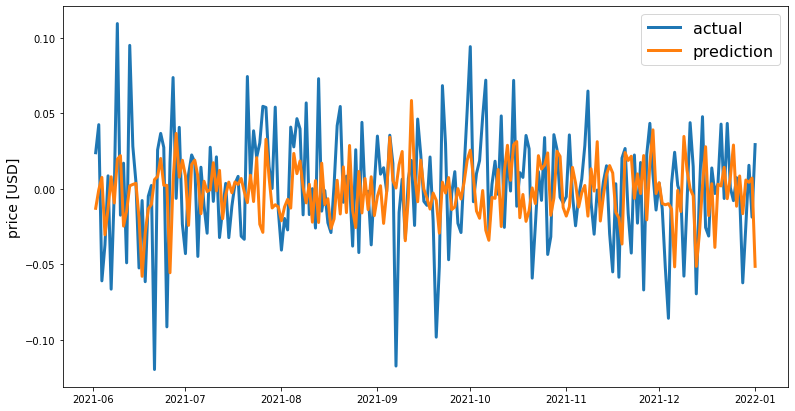

In [65]:
line_plot(targets, preds, 'actual', 'prediction', lw=3)

In [ ]:
#### find the actual price rmse, mae
#actual_price=0.15% of closing price
#pred_price(t)=p(t-1)*exp(pred_log_return)

In [23]:
#4-year,daily data with 1379 datapoints
#lstm: testset=0.15; dropout=0.05
#results are RMSE=0.03759888807042016; R2=0.7653697929481436

#compare with the ones adding ETH price: RMSE=0.03709864805345741; R2=0.7715716053932102

#compare with XGB: RMSE=0.03617884612483444

In [ ]:
#######################

In [281]:
df=pd.read_csv('test_set.csv')
df.head()

,Close,Timestamp,High,Low,Open,log_return
0,37216.28170,1621937700,37523.0000,37109.82538,37268.47447,-0.008390
1,36905.33980,1621938600,37357.0000,36687.93613,37191.21854,-0.008390
2,37121.40202,1621939500,37292.3194,36885.55561,36905.33980,0.005837
3,37052.79393,1621940400,37433.2600,36938.77551,37111.38559,-0.001850
4,37146.44744,1621941300,37232.9191,36717.47957,37043.39449,0.002524


In [282]:
df.agg({ "log_return": ["count","mean","median","min", "max","std", "skew","kurt"]})

,log_return
count,3480.000000
mean,-0.000027
median,-0.000073
min,-0.037190
max,0.036985
std,0.005277
skew,0.187264
kurt,4.992546


In [46]:
import numpy as np
import pandas as pd
import seaborn as sns
import datetime as dt
df=pd.read_csv('btc.csv')
df['Date'] = pd.to_datetime(df.Date)
df.head()
hist = df.set_index('Date')
hist.index = pd.to_datetime(hist.index, unit='s')
target_col = 'Close'
hist.head(5)

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2018-01-01,14112.2002,14112.20020,13154.70020,13657.20020,13657.20020,1.029120e+10
2018-01-02,13625.0000,15444.59961,13163.59961,14982.09961,14982.09961,1.684660e+10
2018-01-03,14978.2002,15572.79981,14844.50000,15201.00000,15201.00000,1.687190e+10
2018-01-04,15270.7002,15739.70020,14522.20020,15599.20020,15599.20020,2.178320e+10
2018-01-05,15477.2002,17705.19922,15202.79981,17429.50000,17429.50000,2.384090e+10


In [49]:
def train_test_split(df, test_size=0.15):
    split_row = len(df) - int(test_size * len(df))
    train_data = df.iloc[:split_row]
    test_data = df.iloc[split_row:]
    return train_data, test_data

In [50]:
train, test = train_test_split(hist, test_size=0.15)

In [51]:

def line_plot(line1, line2, label1=None, label2=None, title='', lw=2):
    fig, ax = plt.subplots(1, figsize=(13, 7))
    ax.plot(line1, label=label1, linewidth=lw)
    ax.plot(line2, label=label2, linewidth=lw)
    plt.xticks(fontsize=17)
    plt.yticks(fontsize=17)
    ax.set_ylabel('BTC Daily Closing Price [USD]', fontsize=18)
    ax.set_title(title, fontsize=17)
    ax.legend(loc='best', fontsize=17);

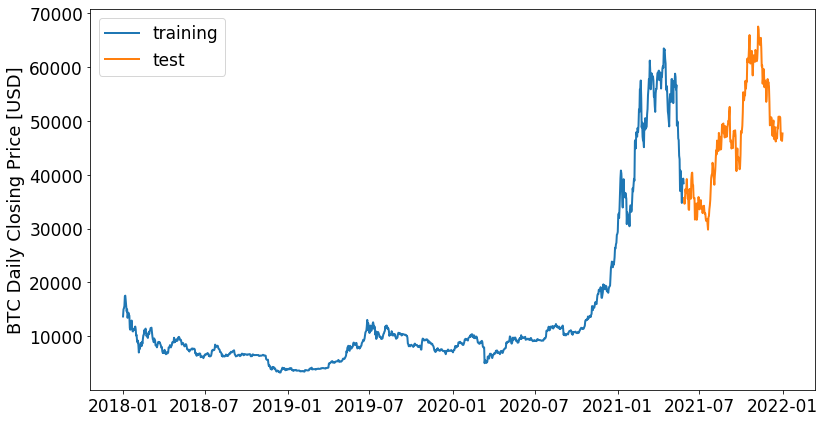

In [52]:
from keras.models import Sequential
from keras.layers import Activation, Dense, Dropout, LSTM
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import mean_absolute_error

line_plot(train[target_col], test[target_col], 'training', 'test', title='')
plt.savefig('my_plot2.png',dpi=300)

In [2]:
#correlation hotmap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
df_result=pd.read_csv('btc_all_feature.csv')
df_result.head()

,Date,High,Low,Close,Log return,Price change,Price volatility,Volume,ETH close,ETH log return,gold_high,gold_low,gold_close,gold_log_return,gold_price_change,gold_price_volatility
0,2018/1/1,14112.20020,13154.70020,13657.20020,0.080000,0.070232,0.042196,1.029120e+10,772.640991,0.100000,"1,317.60","1,302.30",1313.7,0,0.011679835,0.007014536
1,2018/1/2,15444.59961,13163.59961,14982.09961,0.092589,0.159465,0.095972,1.684660e+10,884.443970,0.135145,"1,317.60","1,302.30",1313.7,0,0.011679835,0.007014536
2,2018/1/3,15572.79981,14844.50000,15201.00000,0.014505,0.047887,0.028765,1.687190e+10,962.719971,0.084803,"1,320.10","1,312.10",1316.2,0.001901214,0.006078565,0.003650562
3,2018/1/4,15739.70020,14522.20020,15599.20020,0.025858,0.080464,0.048350,2.178320e+10,980.921997,0.018730,"1,322.00","1,319.40",1319.4,0.002428291,0.001968653,0.001182297
4,2018/1/5,17705.19922,15202.79981,17429.50000,0.110945,0.152085,0.091513,2.384090e+10,997.719971,0.016980,"1,320.30","1,320.30",1320.3,0.000681896,0,0


In [341]:
#dropping columns
df_result.drop(['Date','High','Low','Log return','Price change','Volume',
                'Price volatility','ETH log return','gold_high','gold_low','gold_log_return','gold_price_change','gold_price_volatility'], axis=1, inplace=True)
df=pd.DataFrame(df_result.copy())
df.head()

,Close,ETH close,gold_close
0,13657.20020,772.640991,1313.7
1,14982.09961,884.443970,1313.7
2,15201.00000,962.719971,1316.2
3,15599.20020,980.921997,1319.4
4,17429.50000,997.719971,1320.3


In [345]:
df.dtypes
df['gold_close'] = pd.to_numeric(df['gold_close'],errors = 'coerce')
print(df['gold_close'])

0       1313.7
1       1313.7
2       1316.2
3       1319.4
4       1320.3
         ...  
1457    1810.2
1458    1805.1
1459    1812.7
1460    1827.5
1461    1827.5
Name: gold_close, Length: 1462, dtype: float64


In [348]:
import numpy as np
import pandas as pd
import seaborn as sns
import datetime as dt
import matplotlib.pyplot as mp

correlation_df = df.corr()
print(correlation_df)

               Close  ETH close  gold_close
Close       1.000000   0.919909    0.607297
ETH close   0.919909   1.000000    0.497692
gold_close  0.607297   0.497692    1.000000


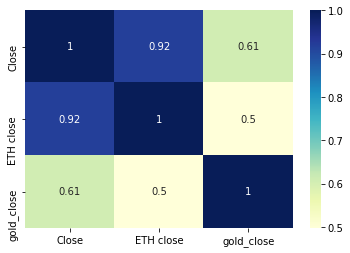

In [350]:
# plotting correlation heatmap
dataplot = sns.heatmap(df.corr(), cmap="YlGnBu", annot=True)
  
# displaying heatmap
mp.show()

In [6]:
##find the 1st order autocorrelation between time series##
return_correl = df_result['Log return']
return_correl
import statsmodels.api as sm
sm.tsa.acf(return_correl)

/Users/jingwenshi/opt/anaconda3/lib/python3.7/site-packages/statsmodels/tsa/stattools.py:572: FutureWarning: fft=True will become the default in a future version of statsmodels. To suppress this warning, explicitly set fft=False.
  FutureWarning


array([ 1.        , -0.05420188,  0.04762477,  0.00424271,  0.04367887,
        0.01807427,  0.03870769, -0.03859054, -0.02090813, -0.01989805,
        0.03877443, -0.00442923, -0.02016002,  0.02418458,  0.02468452,
       -0.00709205,  0.006579  ,  0.044842  , -0.03690132,  0.01989766,
        0.01574955, -0.02134419, -0.01326411, -0.01843053,  0.0048281 ,
       -0.01872534,  0.00340375, -0.004247  ,  0.01002208, -0.04346819,
        0.00417151,  0.03493348, -0.0522474 ,  0.05464141, -0.01699888,
        0.00364277, -0.03089395,  0.03910911,  0.00941479, -0.00151428,
        0.0286906 ])